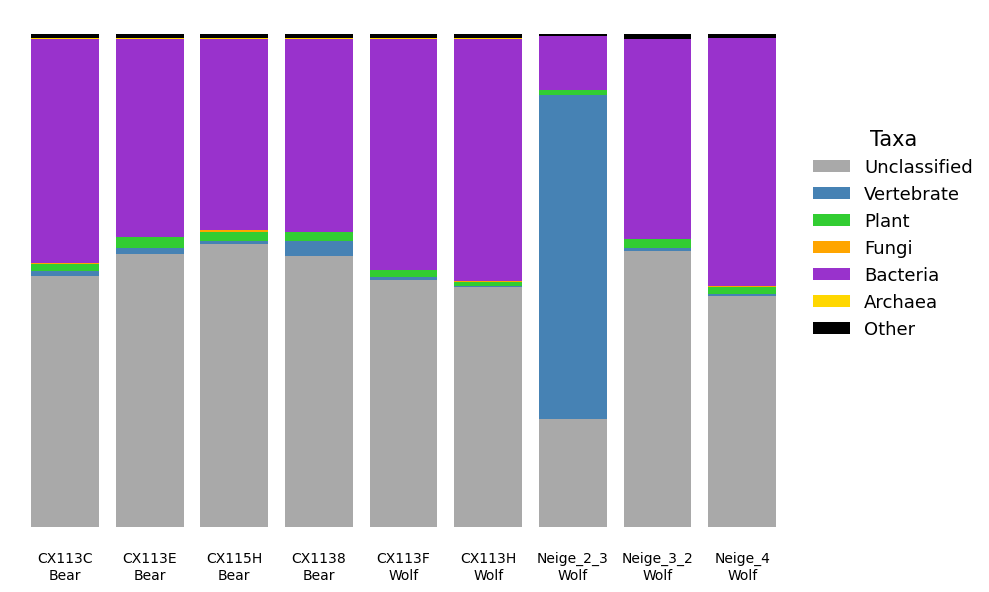

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

samples = ["CX113C","CX113E","CX113F","CX113H","CX115H","CX1138","Neige_2_3","Neige_3_2","Neige_4"]

df_all = pd.DataFrame(columns=[
    "unclassified",
    "Vertebrata",
    "Viridiplantae",
    "Fungi",
    "Bacteria",
    "Archaea",
    "other"
])

for i in range(len(samples)):
    df = pd.read_csv(f"./newdata/report.{samples[i]}.txt", sep='\t', header=None)

    # remove leading spaces
    df[5] = df[5].str.replace(' ', '')

    # keep superkingdoms + unclassified
    filtered_df = df[(df[3].isin(["R2", "U"])) & (df[0] > 0)]
    filtered_df = filtered_df[filtered_df[5] != "Eukaryota"]

    # add Vertebrata (P2 rank)
    vertebrata_row = df[(df[5] == "Vertebrata") & (df[3] == "P2")]

    # add Viridiplantae + Fungi
    extra_rows = df[df[5].isin(["Viridiplantae", "Fungi"])]

    filtered_df = pd.concat([filtered_df, vertebrata_row, extra_rows])

    # fill dataframe + compute "other"
    total_known = 0
    for name in df_all.columns:
        if name == "other":
            continue
        if name in filtered_df[5].values:
            val = filtered_df[filtered_df[5] == name][0].values[0]
            df_all.loc[i, name] = val
            total_known += val
        else:
            df_all.loc[i, name] = 0

    df_all.loc[i, "other"] = max(0, 100 - total_known)

# rename for plotting
df_all.rename(columns={
    'unclassified': 'Unclassified',
    'other': 'Other',
    'Vertebrata': 'Vertebrate',
    'Viridiplantae': 'Plant'
}, inplace=True)

# reorder samples (Bear → Wolf)
desired_order = [
    "CX113C", "CX113E", "CX115H", "CX1138",
    "CX113F", "CX113H", "Neige_2_3", "Neige_3_2", "Neige_4"
]

df_all.index = samples
df_all = df_all.loc[desired_order]

# two-line labels
samples_forplot = [
    "CX113C\nBear","CX113E\nBear","CX115H\nBear","CX1138\nBear",
    "CX113F\nWolf","CX113H\nWolf","Neige_2_3\nWolf","Neige_3_2\nWolf","Neige_4\nWolf"
]

# colours (updated keys)
colour_dict = {
    'Unclassified': 'darkgray',
    'Vertebrate': 'steelblue',
    'Plant': 'limegreen',
    'Fungi': 'orange',
    'Bacteria': 'darkorchid',
    'Archaea': 'gold',
    'Other': 'black'
}

# plot
ax = df_all.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    width=0.8,
    color=[colour_dict[col] for col in df_all.columns]
)

ax.set_xlabel('')
ax.set_ylabel('Proportions')
ax.set_title('')
ax.axis('off')

# larger legend
ax.legend(
    title='Taxa',
    bbox_to_anchor=(1, 0.8),
    loc='upper left',
    frameon=False,
    fontsize=13,
    title_fontsize=15
)

# horizontal, two-line labels
for i, rect in enumerate(ax.patches[0:len(samples)]):
    ax.text(
        rect.get_x() + rect.get_width() / 2.,
        -5,
        samples_forplot[i],
        ha='center',
        va='top',
        rotation=0
    )

plt.tight_layout()
plt.savefig('figures/kraken_output_2.png', dpi=600)
plt.show()

In [7]:
df_all

,Unclassified,Vertebrata,Viridiplantae,Fungi,Bacteria,Archaea,Other
CX113C,50.98,0.85,1.59,0.09,45.46,0.13,0.9
CX113E,55.38,1.19,2.22,0.11,40.03,0.16,0.91
CX115H,57.37,0.64,1.92,0.25,38.8,0.17,0.85
CX1138,54.88,3.05,1.83,0.13,39.12,0.16,0.83
CX113F,50.03,0.69,1.37,0.08,46.82,0.13,0.88
CX113H,48.63,0.3,0.83,0.05,49.24,0.14,0.81
Neige_2_3,21.88,65.65,1.03,0.05,10.98,0.04,0.37
Neige_3_2,55.91,0.68,1.76,0.08,40.52,0.11,0.94
Neige_4,46.83,0.46,1.44,0.06,50.32,0.09,0.8
